# Day 04：手写残差块 —— F(x) + x 的代码奇迹> 🌉 第七周 · ResNet 的奇迹 · 第 4 天昨天我们建立了残差连接的直觉：**让网络学"修正"而不是"全部"**。今天，我们要把直觉变成代码。我们要亲手写一个完整的 `ResidualBlock`，逐行理解它的每一个零件，然后看看这行 `out = F(x) + x` 到底有多大的魔力。**今天的任务**：1. 从零手写一个极简的 `ResidualBlock`2. 逐行理解每一行代码的含义3. 用实验证明：残差块让深层网络"起死回生"---

## 1. 历史剧场：一行代码的诞生2015 年 12 月，何恺明等人的论文 "Deep Residual Learning for Image Recognition" 被 CVPR 2016 接收。论文的核心贡献，浓缩成一行代码就是：

In [ ]:
out = F(x) + x

这行代码有多伟大？- 它让 152 层的网络成功训练（之前 56 层都困难）- 它在 ImageNet 竞赛中以 3.57% 的 Top-5 错误率夺冠（首次超越人类水平 5.1%）- 它是过去十年被引用最多的深度学习论文之一- 它的思想影响了后来几乎所有的深度网络架构**一行代码，改变了深度学习的进程。**---

## 2. 生活隐喻：修图软件的"图层叠加"如果你用过 Photoshop 或修图 App，你一定理解"图层"的概念：- **底层图层**：原始照片（x）- **调整图层**：亮度+10、对比度+5（F(x)）- **最终效果**：原始照片 + 调整 = 最终效果（F(x) + x）关键点：- 如果调整图层是"无调整"（F(x) = 0），最终效果就是原始照片——不会变差- 如果调整图层是"亮度+10"（F(x) = 10），最终效果就是原始照片加亮 10——只改了需要改的- 你永远不需要从零画一张新图，只需要在原图上叠加修改**残差块就是深度学习版的"图层叠加"。**---

<p align="center">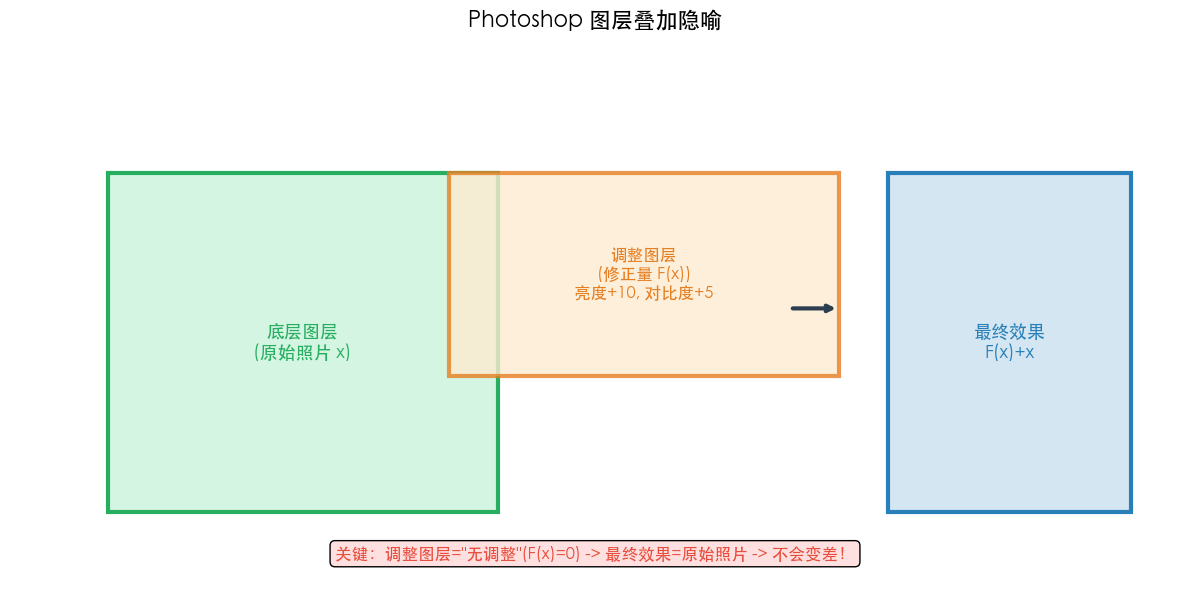</p>*图层叠加隐喻示意图*

## 3. 代码实验室：手写 ResidualBlock### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 先写一个"有缺陷的旧版本"：PlainBlock在引入残差之前，我们先写一个没有残差连接的普通块，看看它的问题。

In [ ]:
class PlainBlock(nn.Module):    """    普通网络块 —— 没有近道的版本    每一层必须从零学起，学不好就全盘崩溃    """    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = self.layer1(x)        out = self.bn1(out)        out = F.relu(out)        out = self.layer2(out)        out = self.bn2(out)        out = F.relu(out)        return out

### 3.3 再写"新版本"：ResidualBlock现在，我们加上那行神奇的代码：

In [ ]:
class ResidualBlock(nn.Module):    """    残差网络块 —— 加了近道的版本    和 PlainBlock 唯一的区别：out = out + identity    """    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = self.layer1(x)        out = self.bn1(out)        out = F.relu(out)        out = self.layer2(out)        out = self.bn2(out)        out = out + identity        out = F.relu(out)        return out

### 逐行解读让我们仔细对比两个版本的 `forward` 方法：| 行号 | PlainBlock | ResidualBlock | 说明 ||---|---|---|---|| 1 | `identity = x` | `identity = x` | 保存输入的副本（残差版后面要用） || 2-4 | 第一层 + BN + ReLU | 第一层 + BN + ReLU | 完全一样 || 5-6 | 第二层 + BN | 第二层 + BN | 完全一样 || **7** | `out = F.relu(out)` | **`out = out + identity`** | **关键区别！加上近道** || 8 | — | `out = F.relu(out)` | 残差版在加法之后才激活 |**唯一的区别就是第 7 行**：`out = out + identity`这一行做了什么？- `out`：经过两层变换后的结果，也就是 F(x)——网络学到的"修正量"- `identity`：原始输入 x- `out + identity`：F(x) + x——修正量叠加到原始输入上---

## 4. 实验见证：残差块让深层网络"起死回生"### 4.1 数据准备

In [ ]:
def make_spiral_data(n_samples=400, noise=0.3):    np.random.seed(42)    n = n_samples // 2    theta_class0 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise    theta_class1 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise + np.pi    r_class0 = theta_class0 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    r_class1 = theta_class1 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    x_class0 = np.column_stack([r_class0 * np.cos(theta_class0), r_class0 * np.sin(theta_class0)])    x_class1 = np.column_stack([r_class1 * np.cos(theta_class1), r_class1 * np.sin(theta_class1)])    X = np.vstack([x_class0, x_class1]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_data, y_data = make_spiral_data()

### 4.2 搭建完整网络

In [ ]:
class DeepNet(nn.Module):    """可配置使用 PlainBlock 或 ResidualBlock 的深层网络"""    def __init__(self, block_type='plain', num_blocks=16, hidden_size=64):        super().__init__()        self.input_layer = nn.Linear(2, hidden_size)        self.input_relu = nn.ReLU()        BlockClass = ResidualBlock if block_type == 'residual' else PlainBlock        self.blocks = nn.Sequential(*[BlockClass(hidden_size) for _ in range(num_blocks)])        self.output_layer = nn.Linear(hidden_size, 1)        self.sigmoid = nn.Sigmoid()    def forward(self, x):        x = self.input_relu(self.input_layer(x))        x = self.blocks(x)        x = self.sigmoid(self.output_layer(x))        return x

### 4.3 训练对比

In [ ]:
def train_and_evaluate(model, X, y, epochs=300, lr=0.01):    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.BCELoss()    losses = []    accuracies = []    for epoch in range(epochs):        predicted_probability = model(X)        loss = loss_fn(predicted_probability, y)        accuracy = ((predicted_probability > 0.5).float() == y).float().mean()        optimizer.zero_grad()        loss.backward()        optimizer.step()        losses.append(loss.item())        accuracies.append(accuracy.item())    return losses, accuraciesnum_blocks = 20torch.manual_seed(42)plain_model = DeepNet(block_type='plain', num_blocks=num_blocks)plain_losses, plain_accs = train_and_evaluate(plain_model, X_data, y_data)torch.manual_seed(42)residual_model = DeepNet(block_type='residual', num_blocks=num_blocks)res_losses, res_accs = train_and_evaluate(residual_model, X_data, y_data)

### 4.4 结果可视化

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(plain_losses, label='PlainBlock', color='#e74c3c', alpha=0.8)axes[0].plot(res_losses, label='ResidualBlock', color='#2ecc71', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Training Loss', fontsize=12)axes[0].set_title(f'{num_blocks} 层网络：训练损失对比', fontsize=14)axes[0].legend(fontsize=12)axes[0].grid(True, alpha=0.3)axes[1].plot(plain_accs, label='PlainBlock', color='#e74c3c', alpha=0.8)axes[1].plot(res_accs, label='ResidualBlock', color='#2ecc71', alpha=0.8)axes[1].set_xlabel('Epoch', fontsize=12)axes[1].set_ylabel('Training Accuracy', fontsize=12)axes[1].set_title(f'{num_blocks} 层网络：训练准确率对比', fontsize=14)axes[1].legend(fontsize=12)axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **PlainBlock**（红色）：20 层的普通网络训练困难，损失居高不下- **ResidualBlock**（绿色）：20 层的残差网络训练顺畅，损失稳步下降唯一的代码区别就是 `out = out + identity` 这一行！---

## 5. 深入理解：残差块内部的信号流让我们追踪信号在残差块内部是如何变化的：

In [ ]:
class InspectableResidualBlock(nn.Module):    """可检查内部信号的残差块"""    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)        self.signals = {}    def forward(self, x):        self.signals['input'] = x.detach().clone()        identity = x        out = self.layer1(x)        out = self.bn1(out)        out = F.relu(out)        self.signals['after_layer1'] = out.detach().clone()        out = self.layer2(out)        out = self.bn2(out)        self.signals['residual_Fx'] = out.detach().clone()        out = out + identity        self.signals['after_add'] = out.detach().clone()        out = F.relu(out)        self.signals['output'] = out.detach().clone()        return outtorch.manual_seed(42)inspect_block = InspectableResidualBlock(64)sample_input = torch.randn(10, 64)_ = inspect_block(sample_input)print("残差块内部信号追踪：\n")for name, tensor in inspect_block.signals.items():    norm = tensor.norm().item()    mean = tensor.mean().item()    std = tensor.std().item()    print(f"  {name:18s} | L2范数: {norm:8.2f} | 均值: {mean:7.4f} | 标准差: {std:7.4f}")print()print("关键观察：")print("  - residual_Fx 是网络学到的'修正量'")print("  - after_add = residual_Fx + input，修正量叠加到原始输入上")print("  - 即使 residual_Fx 很小，input 也能通过近道传过去")

### 解读信号追踪告诉我们：1. **input**：原始输入信号2. **residual_Fx**：网络学到的修正量（通常比输入小很多）3. **after_add**：修正量 + 原始输入 = 最终结果4. **output**：经过 ReLU 后的最终输出关键发现：**修正量 F(x) 通常比输入 x 小得多**。这意味着网络学到的不是"全部"，而是"微调"——这正是残差学习的精髓。---

## 6. 为什么 ReLU 放在加法之后？你可能注意到一个细节：在 `ResidualBlock` 中，ReLU 激活函数放在 `out = out + identity` **之后**，而不是之前。这不是随意的，而是有深刻原因的：

<p align="center">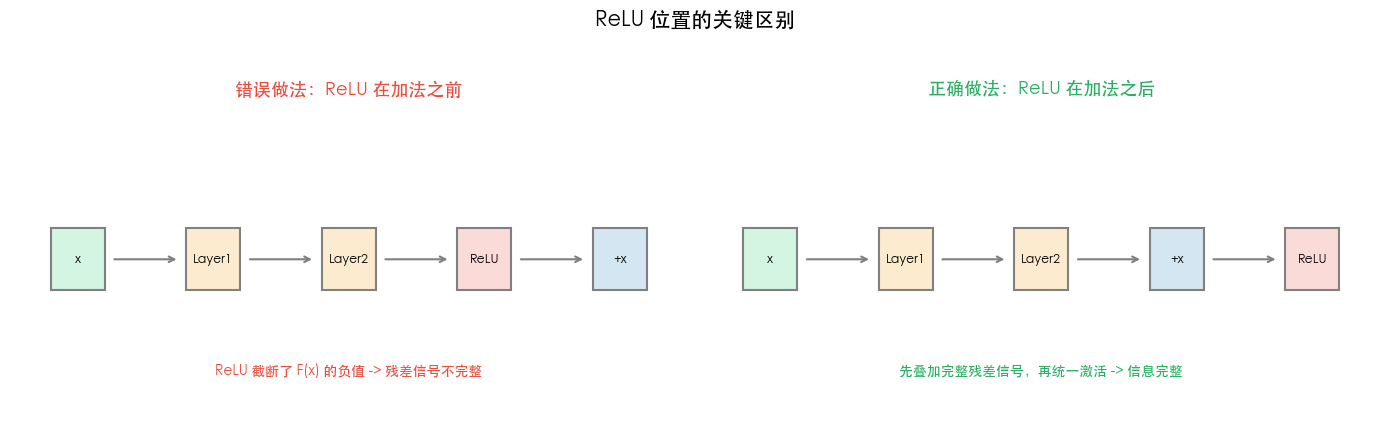</p>*ReLU 位置对比示意图*

In [ ]:
# 普通块：ReLU 在第二层之后立即应用out = self.layer2(out)out = self.bn2(out)out = F.relu(out)     # 激活在加法之前# 残差块：ReLU 在加法之后应用out = self.layer2(out)out = self.bn2(out)out = out + identity   # 先加out = F.relu(out)      # 后激活

**原因**：如果把 ReLU 放在加法之前，F(x) 被 ReLU 截断后可能丢失负值信息，导致残差信号不完整。放在加法之后，保证了 F(x) 的完整信号先叠加到 x 上，再统一做非线性激活。这种设计被称为 **"全预激活"（pre-activation）** 的变体——何恺明在后续论文中进一步优化了这个细节。---

## 今日结语今天我们亲手写了一个完整的 `ResidualBlock`，并理解了它的每一个细节。核心发现：1. **残差块和普通块唯一的区别**就是 `out = out + identity` 这一行2. **这一行让网络从"学全部"变成了"学修正"**——学习任务大幅简化3. **ReLU 放在加法之后**——保证残差信号的完整性明天，我们要进行一场史诗级的对决：Plain Net vs ResNet，看看在更真实的场景下，残差连接到底有多大的优势。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 修图软件的"图层叠加" | 残差块：F(x) + x || 底层图层 = 原始照片 | identity = x（跳跃连接传来的原始输入） || 调整图层 = 亮度+10 | F(x) = 网络学到的修正量 || 最终效果 = 原始 + 调整 | out = F(x) + x || "无调整" = 原图不变 | F(x) = 0，恒等映射 || 先叠加修改再统一处理 | ReLU 放在加法之后 || 修正量通常很小 | 残差 F(x) 的范数通常小于输入 x |